In [6]:
import numpy as np
import re
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [7]:
df = pd.read_csv("fake_and_real_news.csv")

In [8]:

df.head()

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


About the Dataset:

text : the text of the article; could be incomplete
label: a label that marks whether the news article is real or fake:

# preprocessing

In [9]:
df.isnull().sum()

Text     0
label    0
dtype: int64

In [10]:
df.shape

(9900, 2)

In [11]:
X = df.drop('label',axis=1)
y = df['label']

In [12]:
print(X)

                                                   Text
0      Top Trump Surrogate BRUTALLY Stabs Him In The...
1     U.S. conservative leader optimistic of common ...
2     Trump proposes U.S. tax overhaul, stirs concer...
3      Court Forces Ohio To Allow Millions Of Illega...
4     Democrats say Trump agrees to work on immigrat...
...                                                 ...
9895   Wikileaks Admits To Screwing Up IMMENSELY Wit...
9896  Trump consults Republican senators on Fed chie...
9897  Trump lawyers say judge lacks jurisdiction for...
9898   WATCH: Right-Wing Pastor Falsely Credits Trum...
9899   Sean Spicer HILARIOUSLY Branded As Chickensh*...

[9900 rows x 1 columns]


In [13]:
print(y)

0       Fake
1       Real
2       Real
3       Fake
4       Real
        ... 
9895    Fake
9896    Real
9897    Real
9898    Fake
9899    Fake
Name: label, Length: 9900, dtype: object


#Stemming:
Stemming is the process of reducing a word to its Root word
# step

1.  lower case
2. splitting
3. removing stopwords
4. stemming
   



In [14]:
ps = PorterStemmer()
def stemming(content):
    stemmed_content = re.sub('[^a-zA-Z]',' ',content)
    stemmed_content = stemmed_content.lower()
    stemmed_content = stemmed_content.split()
    stemmed_content = [ps.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
    stemmed_content = ' '.join(stemmed_content)
    return stemmed_content

In [15]:
X = df['Text'].values
y = df['label'].values

In [16]:
vector = TfidfVectorizer()
vector.fit(X)
X = vector.transform(X)

In [17]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2171752 stored elements and shape (9900, 58445)>
  Coords	Values
  (0, 4157)	0.022595178512476097
  (0, 4516)	0.04805565447838848
  (0, 4616)	0.11225667081941841
  (0, 4840)	0.025737391221857323
  (0, 4858)	0.09951101615141389
  (0, 5302)	0.026041351687630762
  (0, 5444)	0.026781075708531513
  (0, 5789)	0.04635498534862242
  (0, 6080)	0.07103081090734875
  (0, 6357)	0.021469028075402484
  (0, 6542)	0.07517839739693684
  (0, 6660)	0.06598949552771385
  (0, 6780)	0.04101782310792941
  (0, 7267)	0.036310004404511806
  (0, 7333)	0.050795609570223575
  (0, 7893)	0.019371546427704948
  (0, 7962)	0.08793377766191733
  (0, 8507)	0.047987020107693575
  (0, 8797)	0.06422983007774563
  (0, 10048)	0.0939210186223511
  (0, 10394)	0.02085198627012458
  (0, 10473)	0.019066377865072256
  (0, 10647)	0.09532376412596097
  (0, 10654)	0.03650602685217999
  (0, 10734)	0.027899357773411775
  :	:
  (9899, 56305)	0.022378135432742263
  (9899, 56362

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=2)

In [19]:
X_train.shape

(7920, 58445)

# Training the Model: Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, mean_absolute_error, mean_squared_error)
from sklearn.preprocessing import LabelEncoder
# Logistic Regression classifier

classifier = LogisticRegression()

# Fit the classifier using X_train and Y_train (correcting the variable names)

classifier.fit(X_train, Y_train)

# Predictions

train_y_pred=classifier.predict(X_train)
print("train accuracy :" , accuracy_score(Y_train,train_y_pred))

test_y_pred=classifier.predict(X_test)
print("test accuracy :" , accuracy_score(Y_test,test_y_pred))

# Confusion matrix and classification report for logistic regression

# Correcting the variable name y_test to Y_test

conf_matrix = confusion_matrix(Y_test,test_y_pred)
class_report = classification_report(Y_test,test_y_pred)

print("Logistic Regression - Confusion Matrix:")
print(conf_matrix)
print("\nLogistic Regression - Classification Report:")
print(class_report)

# Calculate and print additional metrics

accuracy = accuracy_score(Y_test, test_y_pred)

# Assuming 'Real' is the positive class for precision and recall calculation

precision = precision_score(Y_test, test_y_pred, pos_label='Real')
recall = recall_score(Y_test, test_y_pred, pos_label='Real')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
#  Convert string labels to numbers for MAE/MSE/RMSE
encoder = LabelEncoder()
Y_test_encoded = encoder.fit_transform(Y_test)
test_y_pred_encoded = encoder.transform(test_y_pred)

# Error metrics
mae = mean_absolute_error(Y_test_encoded, test_y_pred_encoded)
mse = mean_squared_error(Y_test_encoded, test_y_pred_encoded)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


train accuracy : 0.9949494949494949
test accuracy : 0.9863636363636363
Logistic Regression - Confusion Matrix:
[[986  14]
 [ 13 967]]

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      1000
        Real       0.99      0.99      0.99       980

    accuracy                           0.99      1980
   macro avg       0.99      0.99      0.99      1980
weighted avg       0.99      0.99      0.99      1980

Accuracy: 0.99
Precision: 0.99
Recall: 0.99
Mean Absolute Error (MAE): 0.01
Mean Squared Error (MSE): 0.01
Root Mean Squared Error (RMSE): 0.12


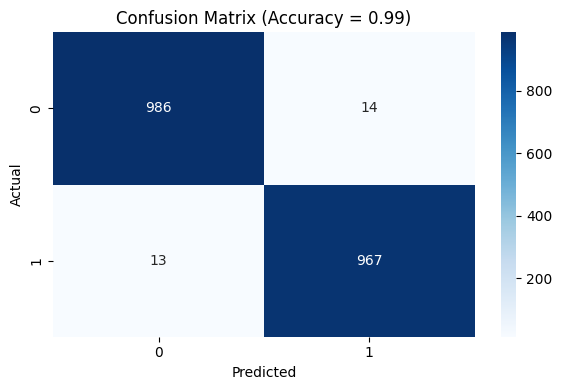

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, test_y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Accuracy = 0.99)')

plt.tight_layout()
plt.show()

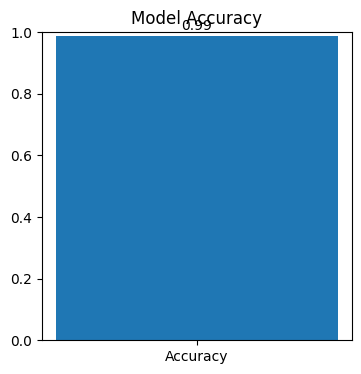

In [22]:
accuracy = accuracy_score(Y_test, test_y_pred)

plt.figure(figsize=(4,4))
plt.bar(['Accuracy'], [accuracy])
plt.ylim(0,1)

plt.title('Model Accuracy')

plt.text(0, accuracy + 0.02, f"{accuracy:.2f}", ha='center')

plt.show()

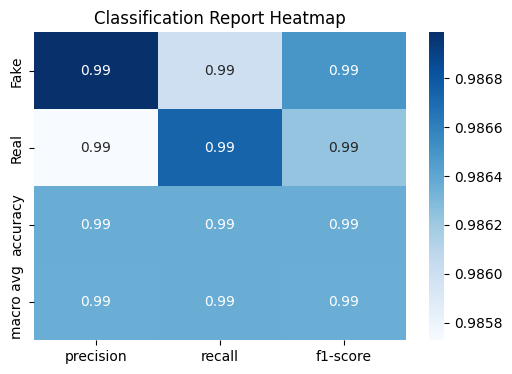

In [23]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(Y_test, test_y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(6,4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap='Blues')

plt.title('Classification Report Heatmap')
plt.show()